# Notebook 01 — Data Ingestion
## market-pulse-nn | Stage 1 of 5

This notebook builds the **raw data layer** for the market movement prediction pipeline.
Every subsequent notebook reads from the files written here.

| Source | Library | Data type | Auth required |
|---|---|---|---|
| Yahoo Finance | `yfinance` | OHLCV price history | None (free) |
| Reuters RSS | `feedparser` | Financial news headlines | None (public) |
| Reddit | `praw` | Posts from finance subreddits | `.env` |
| Twitter / X | `tweepy` | Ticker-related tweets | `.env` |

**Output:** `data/raw/{prices, news, reddit, twitter}/` + `data/raw/manifest.json`

**Estimated runtime:** ~3-5 min locally (Yahoo + RSS + Reddit). Twitter depends on tier.

> Run cells sequentially. Each section saves its output independently
> so any single section can be re-run in isolation without re-running the whole notebook.

In [9]:
# =============================================================================
# CELL 01 | Environment Setup
#
# - Resolves the project root in both VS Code (local/Mac) and Colab environments.
# - Loads CFG (config.py) as the single source of truth for all settings.
# - Fixes random seeds for full reproducibility across all notebooks.
# - Applies a consistent matplotlib style for every plot in this project.
# =============================================================================

import sys, os, json, warnings, re, time
from pathlib import Path
from datetime import datetime, timedelta, timezone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Project root resolution (VS Code + Colab compatible) ─────────────────
try:
    # VS Code: __file__ resolves the notebook path
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    # Jupyter / Colab: __file__ is undefined
    PROJECT_ROOT = Path.cwd().parent
    if not (PROJECT_ROOT / "config.py").exists():
        PROJECT_ROOT = Path.cwd()

sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root : {PROJECT_ROOT}")
print(f"config.py    : {'FOUND' if (PROJECT_ROOT / 'config.py').exists() else 'NOT FOUND -- check path'}")

# ── Central config ────────────────────────────────────────────────────────
from config import CFG
from src.utils.helpers import get_logger, set_seed, ensure_dir

set_seed(CFG.RANDOM_SEED)
logger = get_logger("01_data_ingestion")

# ── Plot style (consistent across all notebooks in this project) ──────────
# One distinctive colour per ticker -- these exact hex values are reused
# in every subsequent notebook so all charts share the same colour legend.
TICKER_COLORS = dict(zip(CFG.TICKERS, [
    "#1565C0",   # AAPL -- deep blue
    "#BF360C",   # TSLA -- burnt orange
    "#2E7D32",   # NVDA -- forest green
    "#6A1B9A",   # MSFT -- purple
    "#E65100",   # AMZN -- amber
]))
SOURCE_COLORS = {
    "yahoo"  : "#1565C0",
    "reuters": "#B71C1C",
    "reddit" : "#E65100",
    "twitter": "#0288D1",
}

plt.rcParams.update({
    "figure.dpi"        : 130,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#F8F9FA",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "font.size"         : 11,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "legend.fontsize"   : 10,
    "legend.framealpha" : 0.85,
})

print(f"Tickers    : {CFG.TICKERS}")
print(f"Date range : {CFG.HIST_START} -> {CFG.HIST_END}")
print(f"Environment: {CFG.ENV} | Device: {CFG.DEVICE}")


Project root : /Users/musarashid/market-pulse-nn
config.py    : FOUND
[set_seed] All seeds fixed to 42
Tickers    : ['AAPL', 'TSLA', 'NVDA', 'MSFT', 'AMZN']
Date range : 2021-01-01 -> 2024-12-31
Environment: local | Device: cpu


---
## 1 · Yahoo Finance -- OHLCV Price Data

**Why first?** Price data is the ground truth for feature engineering and the
prediction target (next-day direction). Every other source will be temporally
aligned to this price timeline.

`yfinance` is free, requires no API key, and returns split/dividend-adjusted
prices for any public ticker. We download 2021-2024 in one call per ticker.

**Schema produced per ticker:**

| Column | Type | Notes |
|---|---|---|
| `date` | datetime64 | Trading day |
| `open / high / low / close` | float64 | OHLC prices |
| `adj_close` | float64 | Adjusted for splits and dividends |
| `volume` | int64 | Shares traded that day |
| `ticker` | str | Ticker symbol |
| `log_return` | float64 | ln(close_t / close_{t-1}) |
| `direction` | int8 | **Target**: 1 if tomorrow's close > today's, else 0 |

In [10]:
# =============================================================================
# CELL 03 | Yahoo Finance Download
#
# Downloads OHLCV history for every ticker in CFG.TICKERS.
#
# Two derived columns are added immediately after download:
#   log_return : ln(close_t / close_{t-1})
#                Better than raw price difference for ML -- proportional,
#                symmetric, and approximately normally distributed.
#   direction  : 1 if tomorrow's close > today's, else 0
#                This is the TARGET LABEL. We shift close by -1 so today's
#                row already carries tomorrow's label for supervised learning.
#
# The final row is always dropped: it has no "tomorrow" to label.
# =============================================================================

import yfinance as yf


def download_price_data(tickers: list, start: str, end: str) -> dict:
    """
    Fetches OHLCV data for each ticker from Yahoo Finance.

    Parameters
    ----------
    tickers : list of ticker symbols, e.g. ['AAPL', 'TSLA']
    start   : start date 'YYYY-MM-DD'
    end     : end date   'YYYY-MM-DD'

    Returns
    -------
    dict[str, pd.DataFrame] -- one cleaned DataFrame per ticker
    """
    results = {}

    for ticker in tickers:
        print(f"  Downloading {ticker}...", end=" ", flush=True)
        try:
            raw = yf.download(
                ticker,
                start=start,
                end=end,
                progress=False,
                auto_adjust=False,  # keeps raw OHLC + adj_close separate
            )

            if raw.empty:
                print("WARNING: no data returned -- skipping.")
                continue

            # yfinance >= 0.2 may return MultiIndex columns -- flatten them
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = [col[0].lower().replace(" ", "_") for col in raw.columns]
            else:
                raw.columns = [c.lower().replace(" ", "_") for c in raw.columns]

            # Standardise the adjusted-close column name
            for alt in ["adj close", "adj_close", "adjclose"]:
                if alt in raw.columns:
                    raw = raw.rename(columns={alt: "adj_close"})
                    break

            raw = raw.reset_index()
            raw.columns = [c.lower().replace(" ", "_") for c in raw.columns]
            raw["date"]   = pd.to_datetime(raw.get("date", raw.get("datetime")))
            raw["ticker"] = ticker

            # Log return: proportional daily move, well-behaved for gradient descent
            raw["log_return"] = np.log(raw["close"] / raw["close"].shift(1))

            # Direction label: shift by -1 so row t holds label for t+1
            raw["direction"] = (raw["close"].shift(-1) > raw["close"]).astype(int)

            # Drop the last row -- it has no tomorrow to label
            raw = raw.iloc[:-1].reset_index(drop=True)
            results[ticker] = raw

            up_pct = raw["direction"].mean()
            print(
                f"OK | {len(raw):,} trading days | "
                f"up {up_pct:.1%} | "
                f"{raw['date'].min().date()} -> {raw['date'].max().date()}"
            )

        except Exception as exc:
            print(f"FAILED -- {exc}")
            logger.error(f"{ticker}: download error -- {exc}")

    return results


# ── Execute ───────────────────────────────────────────────────────────────
print("── Yahoo Finance download ────────────────────────────────────────────")
price_data = download_price_data(CFG.TICKERS, CFG.HIST_START, CFG.HIST_END)

print(f"\n Downloaded {len(price_data)}/{len(CFG.TICKERS)} tickers successfully.")


── Yahoo Finance download ────────────────────────────────────────────

 Downloaded 5/5 tickers successfully.


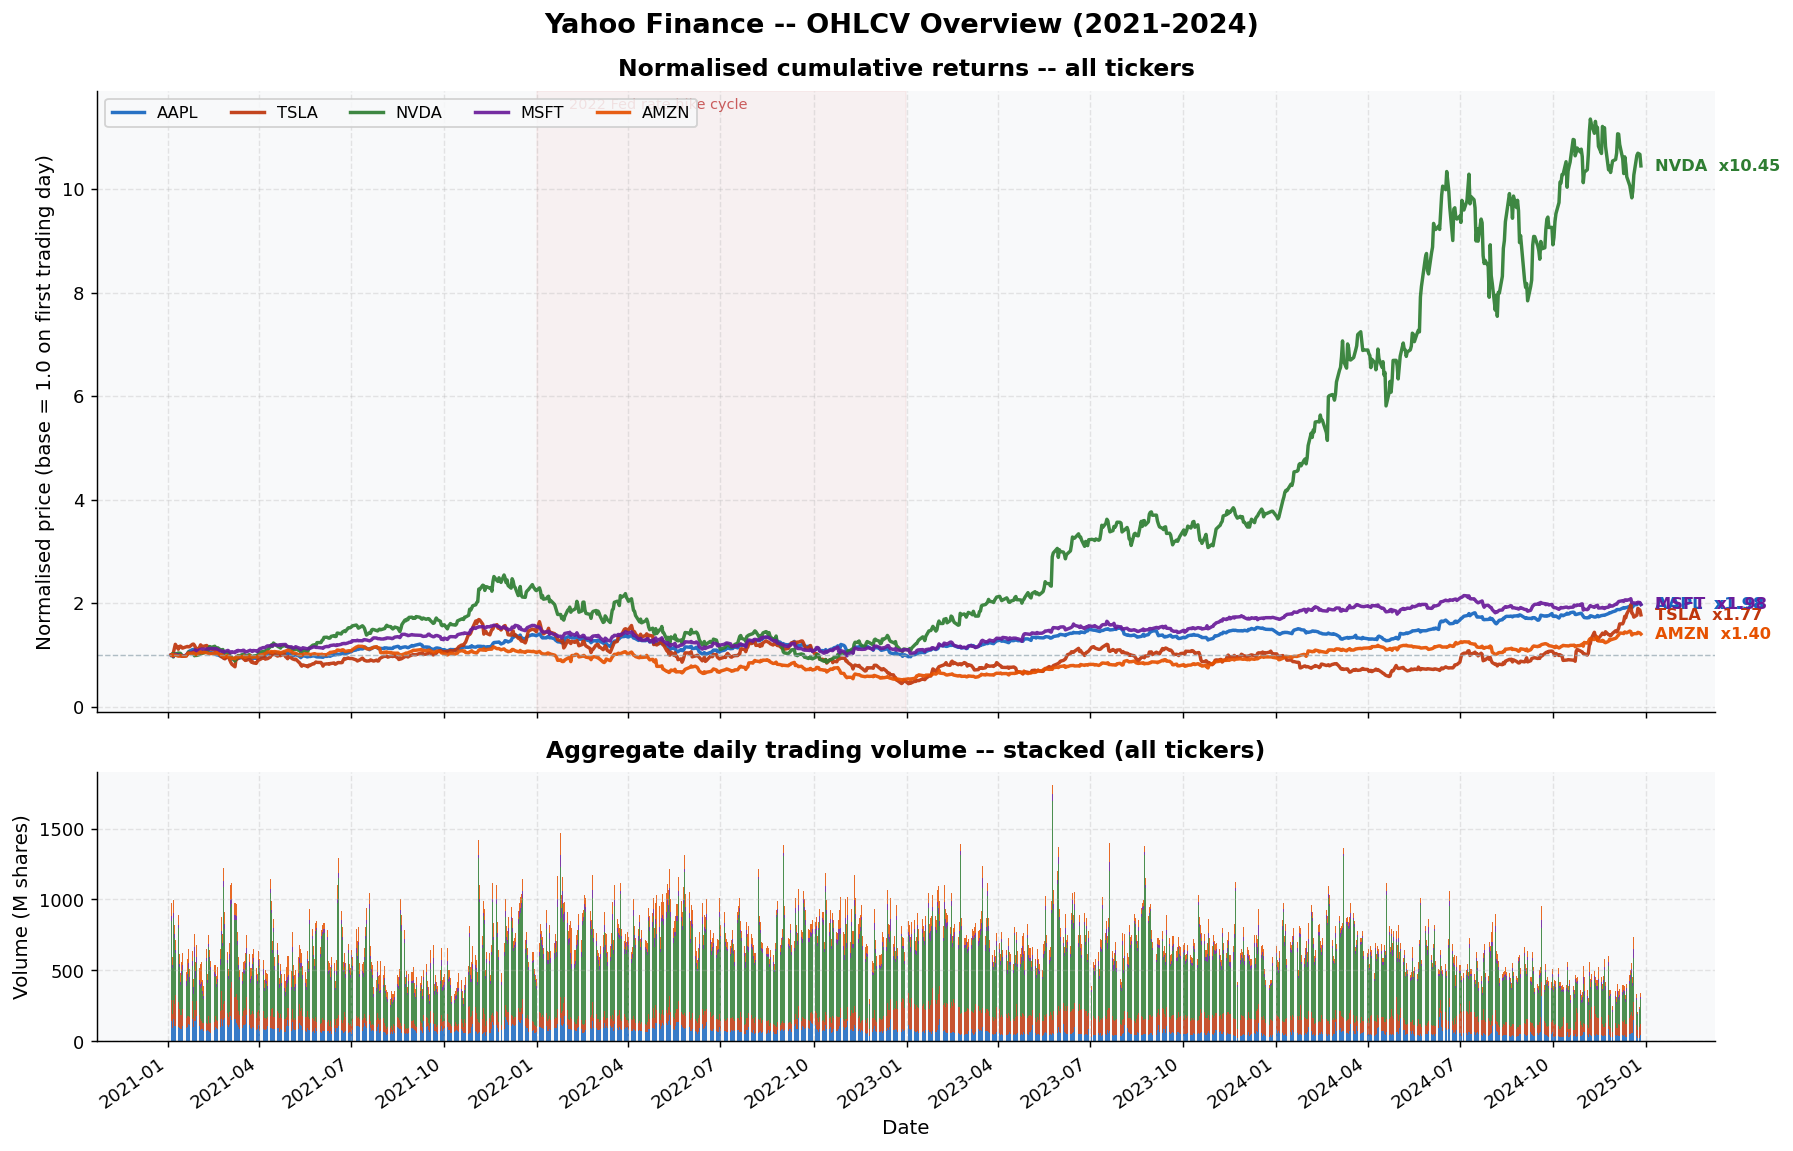

Saved -> /Users/musarashid/market-pulse-nn/reports/figures/01_yf_price_volume.png


In [11]:
# =============================================================================
# CELL 04 | Plot 1 -- Normalised Cumulative Returns + Stacked Volume
#
# Two-panel figure:
#   Top   : All tickers indexed to 1.0 on the first trading day.
#           Removing absolute price level lets us compare growth directly.
#           Annotated with each ticker's final cumulative multiplier.
#   Bottom: Stacked daily volume (millions of shares).
#           Volume spikes often precede or coincide with significant moves.
# =============================================================================

fig, (ax_price, ax_vol) = plt.subplots(
    2, 1, figsize=(14, 9), height_ratios=[3, 1.3], sharex=True
)
fig.suptitle("Yahoo Finance -- OHLCV Overview (2021-2024)", fontsize=15, fontweight="bold")

# ── Top: Normalised cumulative returns ────────────────────────────────────
for ticker, df in price_data.items():
    norm = df["close"] / df["close"].iloc[0]   # index to 1.0 at start
    ax_price.plot(
        df["date"], norm,
        label=ticker,
        color=TICKER_COLORS[ticker],
        linewidth=1.9,
        alpha=0.92,
    )
    # Annotate final multiplier at the right edge
    ax_price.annotate(
        f"{ticker}  x{norm.iloc[-1]:.2f}",
        xy=(df["date"].iloc[-1], norm.iloc[-1]),
        xytext=(8, 0),
        textcoords="offset points",
        color=TICKER_COLORS[ticker],
        fontsize=9, fontweight="bold", va="center",
    )

# Break-even reference line
ax_price.axhline(1.0, color="#90A4AE", linewidth=0.8, linestyle="--", alpha=0.7)

# Shade 2022 rate-hike cycle for contextual annotation
ax_price.axvspan(
    pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
    alpha=0.05, color="#EF5350",
)
ymax = ax_price.get_ylim()[1]
ax_price.text(
    pd.Timestamp("2022-02-01"), ymax * 0.97,
    "2022 Fed rate hike cycle",
    fontsize=8, color="#B71C1C", alpha=0.7,
)

ax_price.set_ylabel("Normalised price (base = 1.0 on first trading day)")
ax_price.legend(loc="upper left", ncols=len(CFG.TICKERS), fontsize=9)
ax_price.set_title("Normalised cumulative returns -- all tickers", pad=8)

# ── Bottom: Stacked daily trading volume ──────────────────────────────────
all_vol = pd.concat(
    [df[["date", "volume"]].assign(ticker=t) for t, df in price_data.items()]
)
vol_pivot = (
    all_vol.pivot_table(index="date", columns="ticker", values="volume")
    .fillna(0) / 1e6   # convert to millions of shares
)

bottom = np.zeros(len(vol_pivot))
for ticker in CFG.TICKERS:
    if ticker not in vol_pivot.columns:
        continue
    ax_vol.bar(
        vol_pivot.index,
        vol_pivot[ticker],
        bottom=bottom,
        color=TICKER_COLORS[ticker],
        width=1.0,
        alpha=0.85,
        label=ticker,
    )
    bottom += vol_pivot[ticker].values

ax_vol.set_ylabel("Volume (M shares)")
ax_vol.set_xlabel("Date")
ax_vol.set_title("Aggregate daily trading volume -- stacked (all tickers)", pad=8)
ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_vol.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
plt.setp(ax_vol.xaxis.get_majorticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig(CFG.FIGURES / "01_yf_price_volume.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved -> {CFG.FIGURES / '01_yf_price_volume.png'}")


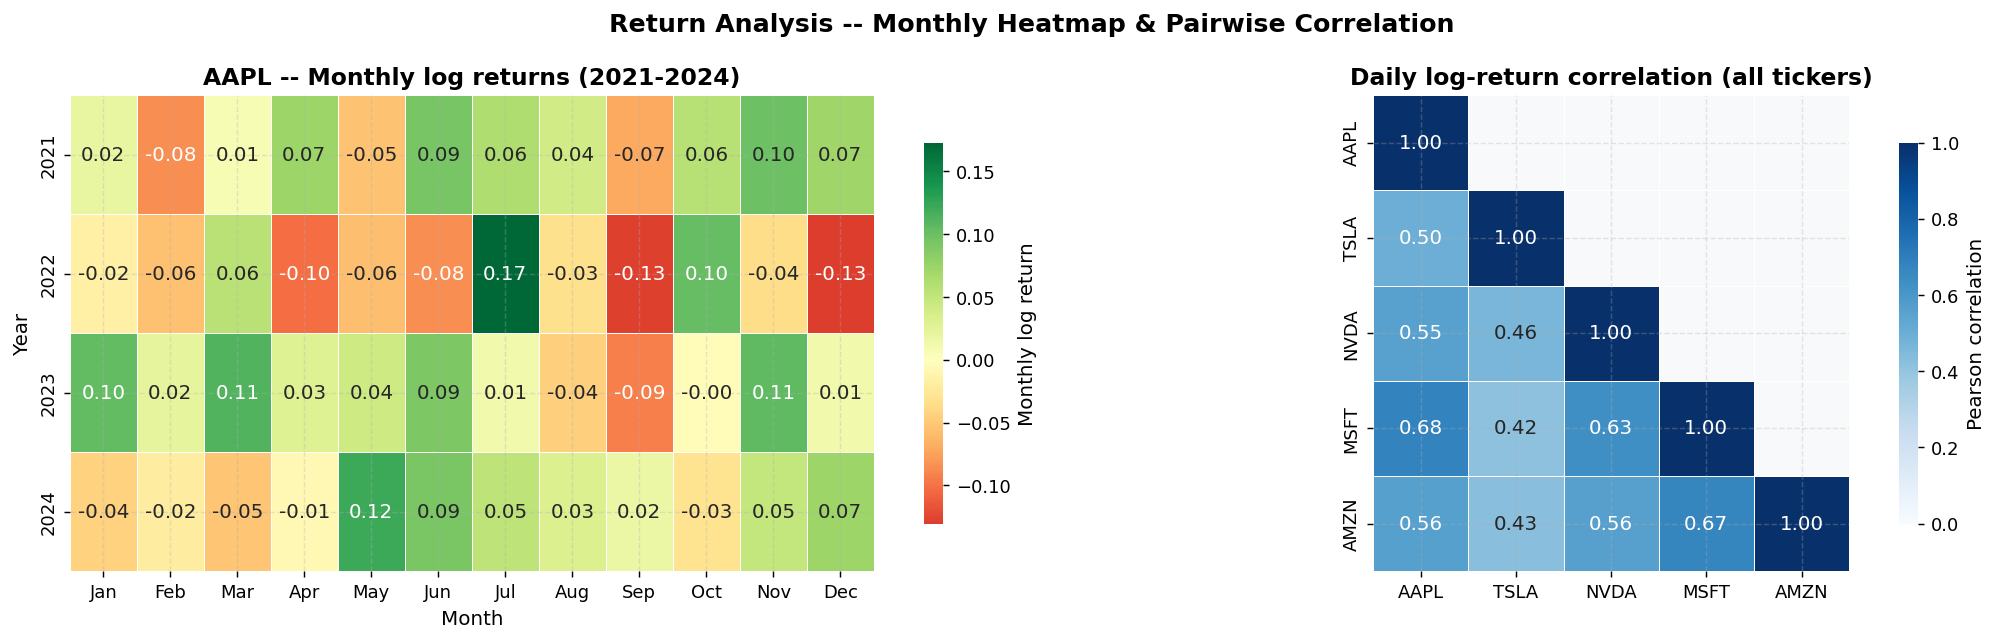

Saved -> /Users/musarashid/market-pulse-nn/reports/figures/01_yf_return_analysis.png

-- Direction label (target) class balance ────────────────────────────
  AAPL: Up=533 (53.1%)  Down=470 (46.9%)
  TSLA: Up=521 (51.9%)  Down=482 (48.1%)
  NVDA: Up=538 (53.6%)  Down=465 (46.4%)
  MSFT: Up=519 (51.7%)  Down=484 (48.3%)
  AMZN: Up=515 (51.3%)  Down=488 (48.7%)

NOTE: markets trend upward long-term, so Up days slightly exceed Down days.
      The mild imbalance will be handled with weighted F1-score in evaluation.


In [12]:
# =============================================================================
# CELL 05 | Plot 2 -- Monthly Returns Heatmap & Pairwise Correlation Matrix
#
# Left : Monthly log-return heatmap for AAPL.
#        Red = losing months, Green = winning months.
#        Reveals seasonality patterns and the 2022 drawdown visually.
#        Change `focus_ticker` to explore any other ticker.
#
# Right: Pairwise daily return correlation matrix for all tickers.
#        High correlation means tickers move together, reducing the independent
#        signal in each one. Important context for feature selection later.
# =============================================================================

fig, (ax_heat, ax_corr) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Return Analysis -- Monthly Heatmap & Pairwise Correlation", fontsize=14, fontweight="bold")

# ── Left: Monthly return heatmap ──────────────────────────────────────────
focus_ticker = "AAPL"   # change to any ticker in CFG.TICKERS to explore
df_focus = price_data[focus_ticker].copy()
df_focus["year"]  = df_focus["date"].dt.year
df_focus["month"] = df_focus["date"].dt.month

# Sum log returns within each calendar month
monthly_ret = df_focus.groupby(["year", "month"])["log_return"].sum().unstack()
monthly_ret.columns = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

sns.heatmap(
    monthly_ret,
    ax=ax_heat,
    cmap="RdYlGn",     # diverging: red = negative, green = positive
    center=0,
    annot=True, fmt=".2f",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Monthly log return", "shrink": 0.8},
)
ax_heat.set_title(f"{focus_ticker} -- Monthly log returns (2021-2024)")
ax_heat.set_xlabel("Month")
ax_heat.set_ylabel("Year")

# ── Right: Pairwise daily return correlation ──────────────────────────────
# Build a matrix: rows = trading dates, columns = tickers
returns_df = pd.concat(
    [df.set_index("date")["log_return"].rename(t) for t, df in price_data.items()],
    axis=1,
).dropna()   # drop rows with any NaN (first row of each ticker after log-diff)

corr_matrix = returns_df.corr()

# Mask upper triangle to avoid duplicating the symmetric information
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax_corr,
    mask=mask,
    cmap="Blues",
    vmin=0.0, vmax=1.0,
    annot=True, fmt=".2f",
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
)
ax_corr.set_title("Daily log-return correlation (all tickers)")

plt.tight_layout()
plt.savefig(CFG.FIGURES / "01_yf_return_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved -> {CFG.FIGURES / '01_yf_return_analysis.png'}")

# ── Class balance check ───────────────────────────────────────────────────
# Up-day percentage tells us whether we need class weights in the loss function.
print("\n-- Direction label (target) class balance ────────────────────────────")
for ticker, df in price_data.items():
    up_pct = df["direction"].mean()
    print(f"  {ticker}: Up={df['direction'].sum():,} ({up_pct:.1%})  "
          f"Down={(~df['direction'].astype(bool)).sum():,} ({1-up_pct:.1%})")
print("\nNOTE: markets trend upward long-term, so Up days slightly exceed Down days.")
print("      The mild imbalance will be handled with weighted F1-score in evaluation.")


In [13]:
# =============================================================================
# CELL 06 | Save Price Data + Display Final Schema
# Saves one CSV per ticker to data/raw/prices/.
# Metadata collected here flows into the master manifest.json at the end.
# =============================================================================

price_manifest = {}

for ticker, df in price_data.items():
    out_path = CFG.PRICES / f"{ticker}_daily.csv"
    df.to_csv(out_path, index=False)

    price_manifest[ticker] = {
        "file"    : out_path.name,
        "rows"    : len(df),
        "start"   : str(df["date"].min().date()),
        "end"     : str(df["date"].max().date()),
        "columns" : list(df.columns),
        "up_pct"  : round(float(df["direction"].mean()), 4),
    }
    print(f"  Saved {out_path.name}  ({len(df):,} rows, {df.shape[1]} cols)")

# Display the schema using the first ticker as a representative sample
ref_ticker = CFG.TICKERS[0]
ref_df = price_data[ref_ticker]
print(f"\n-- Column schema ({ref_ticker}) ─────────────────────────────────────")
print(f"{'Column':<16} {'Dtype':<14} {'Sample value'}")
print("-" * 50)
for col in ref_df.columns:
    sample = ref_df[col].iloc[1]
    print(f"  {col:<14} {str(ref_df[col].dtype):<14} {sample!r}")

print(f"\n All price data saved to: {CFG.PRICES}")


  Saved AAPL_daily.csv  (1,003 rows, 10 cols)
  Saved TSLA_daily.csv  (1,003 rows, 10 cols)
  Saved NVDA_daily.csv  (1,003 rows, 10 cols)
  Saved MSFT_daily.csv  (1,003 rows, 10 cols)
  Saved AMZN_daily.csv  (1,003 rows, 10 cols)

-- Column schema (AAPL) ─────────────────────────────────────
Column           Dtype          Sample value
--------------------------------------------------
  date           datetime64[ns] Timestamp('2021-01-05 00:00:00')
  adj_close      float64        127.4127197265625
  close          float64        131.00999450683594
  high           float64        131.74000549316406
  low            float64        128.42999267578125
  open           float64        128.88999938964844
  volume         int64          97664900
  ticker         object         'AAPL'
  log_return     float64        0.012287927104146933
  direction      int64          0

 All price data saved to: /Users/musarashid/market-pulse-nn/data/raw/prices


---
## 2 · Reuters RSS -- Financial News

RSS feeds are the cleanest free source of timestamped financial headlines.
Reuters publishes several public feeds that update every few minutes.

**Why RSS over web scraping?**
- No JavaScript rendering -- `feedparser` retrieves structured XML directly.
- Articles include `published_parsed` timestamps in UTC -- no timezone guessing.
- Legally clear -- RSS is designed for automated consumption.

**Schema produced:**

| Column | Type | Notes |
|---|---|---|
| `source` | str | Feed label, e.g. `reuters_businessNews` |
| `title` | str | Article headline |
| `summary` | str | Lede paragraph / description |
| `published` | datetime (UTC) | Publication timestamp |
| `link` | str | Article URL |
| `author` | str or NaN | Byline if provided by feed |
| `text` | str | `title + ". " + summary` -- direct input to FinBERT |

In [14]:
# =============================================================================
# CELL 08 | Reuters RSS Scraper
#
# Parses each feed URL in CFG.RSS_FEEDS using feedparser.
# feedparser returns a structured dict per entry -- no HTML parsing required.
#
# Gotchas handled here:
#   - Deduplication: same article often appears across multiple feeds.
#   - Timestamp normalisation: RSS uses RFC 2822 OR ISO 8601 -- we handle both.
#   - HTML stripping: summaries sometimes contain residual <p> tags.
#   - Bozo flag: feedparser sets bozo=True for malformed XML -- we log and skip.
# =============================================================================

import feedparser
from email.utils import parsedate_to_datetime


def parse_rss_feeds(feeds: list, max_per_feed: int = 200) -> pd.DataFrame:
    """
    Parses a list of RSS feed URLs and returns a deduplicated DataFrame.

    Parameters
    ----------
    feeds        : list of RSS feed URLs
    max_per_feed : maximum articles to retain per feed (avoid memory blowout)

    Returns
    -------
    pd.DataFrame with columns: source, title, summary, published, link, author, text
    """
    all_articles = []
    seen_links   = set()   # deduplication: skip articles already collected

    for feed_url in feeds:
        # Build a short human-readable source label from the URL path
        source_label = feed_url.split("/")[-1].replace("News", "").lower()
        source_label = f"reuters_{source_label}" if source_label else "reuters"

        print(f"  Fetching {feed_url} ...", end=" ", flush=True)
        parsed = feedparser.parse(feed_url)

        if parsed.bozo and not parsed.entries:
            print(f"WARN: bozo feed ({type(parsed.bozo_exception).__name__}) -- skipping.")
            continue

        count = 0
        for entry in parsed.entries[:max_per_feed]:
            link = entry.get("link", "")
            if link in seen_links:
                continue   # already have this article from another feed
            seen_links.add(link)

            # Parse publication timestamp -- prefer the structured parsed version
            try:
                if getattr(entry, "published_parsed", None):
                    ts = pd.Timestamp(
                        datetime(*entry.published_parsed[:6], tzinfo=timezone.utc)
                    )
                elif entry.get("published"):
                    ts = pd.Timestamp(parsedate_to_datetime(entry["published"]))
                else:
                    ts = pd.NaT
            except Exception:
                ts = pd.NaT

            title   = entry.get("title",   "").strip()
            raw_sum = entry.get("summary", entry.get("description", ""))
            # Strip any residual HTML tags from the summary text
            summary = re.sub(r"<[^>]+>", " ", raw_sum).strip()
            summary = re.sub(r"\s+", " ", summary)

            all_articles.append({
                "source"   : source_label,
                "title"    : title,
                "summary"  : summary,
                "published": ts,
                "link"     : link,
                "author"   : entry.get("author", np.nan),
                # text = what gets sent to FinBERT in Notebook 02
                "text"     : f"{title}. {summary}".strip(),
            })
            count += 1

        print(f"OK | {count} articles")

    if not all_articles:
        print("\nWARN: No articles retrieved -- check feed URLs or internet connection.")
        return pd.DataFrame()

    df = pd.DataFrame(all_articles)
    df["published"] = pd.to_datetime(df["published"], utc=True)
    df = df.sort_values("published", ascending=False).reset_index(drop=True)
    return df


# ── Execute ───────────────────────────────────────────────────────────────
print("── Reuters RSS fetch ────────────────────────────────────────────────")
news_df = parse_rss_feeds(CFG.RSS_FEEDS, max_per_feed=CFG.RSS_MAX_ARTICLES)

if not news_df.empty:
    print(f"\nTotal articles  : {len(news_df):,}")
    print(f"Date range      : {news_df['published'].min()} -> {news_df['published'].max()}")
    print(f"Sources         : {news_df['source'].value_counts().to_dict()}")
    print(f"Null timestamps : {news_df['published'].isna().sum()}")
    print(f"\nSample: {news_df['title'].iloc[0]!r}")


── Reuters RSS fetch ────────────────────────────────────────────────
  Fetching https://finance.yahoo.com/news/rssindex ... OK | 47 articles
  Fetching https://feeds.content.dowjones.io/public/rss/mw_realtimeheadlines ... OK | 10 articles
  Fetching https://www.investing.com/rss/news_25.rss ... OK | 10 articles
  Fetching https://www.marketwatch.com/rss/topstories ... OK | 10 articles

Total articles  : 77
Date range      : 2024-02-27 12:40:00+00:00 -> 2026-05-11 21:19:00+00:00
Sources         : {'reuters_rssindex': 47, 'reuters_topstories': 10, 'reuters_news_25.rss': 10, 'reuters_mw_realtimeheadlines': 10}
Null timestamps : 0

Sample: 'Cash-strapped homeowners may soon have no choice but to repair their aging houses. These stocks can benefit.'


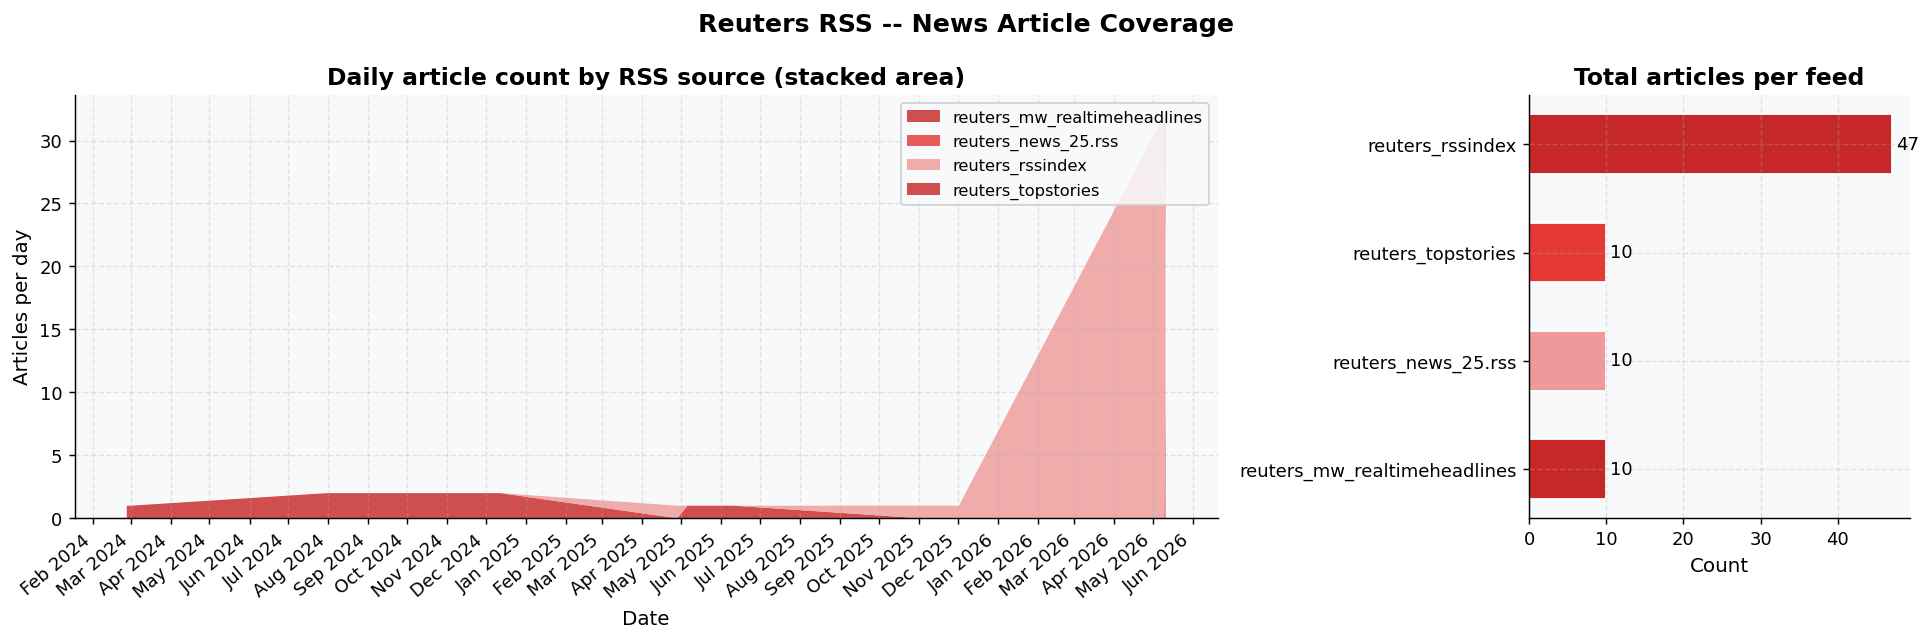

Saved -> /Users/musarashid/market-pulse-nn/reports/figures/01_news_coverage.png


In [15]:
# =============================================================================
# CELL 09 | Plot 3 -- News Article Coverage Timeline
#
# Left : Stacked area chart showing articles per day per RSS source.
#        Gaps in coverage mean no news signal that day -- these days will
#        get forward-filled sentiment scores in Notebook 03.
#
# Right: Horizontal bar showing total article counts per source.
#        Useful sanity check that feeds are delivering expected volumes.
# =============================================================================

if news_df.empty:
    print("No news data available -- skipping plot.")
else:
    shades = ["#C62828", "#E53935", "#EF9A9A"]

    fig, (ax_time, ax_src) = plt.subplots(
        1, 2, figsize=(15, 5),
        gridspec_kw={"width_ratios": [3, 1]}
    )
    fig.suptitle("Reuters RSS -- News Article Coverage", fontsize=14, fontweight="bold")

    # ── Left: Daily article count (stacked area) ──────────────────────────
    news_daily = news_df.copy()
    news_daily["date"] = news_daily["published"].dt.date
    daily_pivot = (
        news_daily.groupby(["date", "source"])
        .size().unstack(fill_value=0)
    )
    daily_pivot.index = pd.to_datetime(daily_pivot.index)
    sources = list(daily_pivot.columns)

    ax_time.stackplot(
        daily_pivot.index,
        [daily_pivot[s] for s in sources],
        labels=sources,
        colors=shades[:len(sources)],
        alpha=0.82,
    )
    ax_time.set_title("Daily article count by RSS source (stacked area)")
    ax_time.set_ylabel("Articles per day")
    ax_time.set_xlabel("Date")
    ax_time.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax_time.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax_time.xaxis.get_majorticklabels(), rotation=40, ha="right")
    ax_time.legend(loc="upper right", fontsize=9)

    # ── Right: Article count per source ──────────────────────────────────
    src_counts = news_df["source"].value_counts()
    bars = ax_src.barh(
        src_counts.index, src_counts.values,
        color=shades[:len(src_counts)],
        edgecolor="white", height=0.55,
    )
    for bar, val in zip(bars, src_counts.values):
        ax_src.text(
            val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10,
        )
    ax_src.set_title("Total articles per feed")
    ax_src.set_xlabel("Count")
    ax_src.invert_yaxis()

    plt.tight_layout()
    plt.savefig(CFG.FIGURES / "01_news_coverage.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved -> {CFG.FIGURES / '01_news_coverage.png'}")


In [16]:
# =============================================================================
# CELL 10 | Save News Data
# Serialises news DataFrame to JSON (records orientation).
# Timestamps converted to ISO strings for JSON compatibility.
# =============================================================================

news_manifest = {}

if not news_df.empty:
    out_path = CFG.NEWS / "reuters_articles.json"
    export = news_df.copy()
    export["published"] = export["published"].apply(
        lambda ts: ts.isoformat() if pd.notna(ts) else None
    )
    export.to_json(out_path, orient="records", indent=2, force_ascii=False)

    news_manifest = {
        "file"     : out_path.name,
        "rows"     : len(news_df),
        "sources"  : news_df["source"].value_counts().to_dict(),
        "start"    : str(news_df["published"].min()),
        "end"      : str(news_df["published"].max()),
        "columns"  : list(news_df.columns),
        "saved_at" : datetime.now().isoformat(timespec="seconds"),
    }
    print(f"Saved {out_path.name}  ({len(news_df):,} articles)")
else:
    print("WARN: No news data to save.")
    print("      RSS feeds may be temporarily unavailable.")
    print("      Re-run this cell once connectivity is restored.")


Saved reuters_articles.json  (77 articles)


---
## 3 · Reddit -- Social Sentiment Data

Reddit finance communities generate high-volume retail investor sentiment,
often ahead of or alongside significant price action.

**PRAW** (Python Reddit API Wrapper) handles OAuth2 automatically.
Rate limit: 60 requests/minute on a free developer account (auto-managed by PRAW).

**Subreddits monitored:**
- `r/wallstreetbets` -- high-noise, high-signal retail meme-stock sentiment
- `r/stocks` -- earnings commentary, fundamental analysis
- `r/investing` -- long-term and macro-focused discussion
- `r/finance` -- institutional-leaning discussion

**Setup required:** Copy `.env.example` to `.env` and fill in:
- `REDDIT_CLIENT_ID`
- `REDDIT_CLIENT_SECRET`

Get credentials at https://www.reddit.com/prefs/apps (create a "script" app).

**Schema produced:**

| Column | Type | Notes |
|---|---|---|
| `post_id` | str | Reddit internal post ID |
| `subreddit` | str | Community name |
| `title` | str | Post title |
| `selftext` | str | Post body (empty for link posts) |
| `author` | str | Username |
| `score` | int | Net upvotes (upvotes - downvotes) |
| `upvote_ratio` | float | Fraction of votes that are upvotes |
| `num_comments` | int | Total reply count |
| `created_utc` | datetime (UTC) | Post creation time |
| `text` | str | `title + " " + selftext` -- input to FinBERT |

In [ ]:
# =============================================================================
# CELL 12 | Reddit Scraper (PRAW)
#
# Scrapes the `new` sort of each subreddit in CFG.REDDIT_SUBREDDITS.
# `new` gives us the most recent posts regardless of score -- essential for
# capturing time-sensitive sentiment close to market events.
#
# PRAW automatically handles the 60 req/min rate limit.
# We add a 1s sleep between subreddits as an additional courtesy.
#
# Deleted/removed posts are skipped -- they contain no signal.
# =============================================================================

import praw
from praw.exceptions import PRAWException


def get_reddit_client():
    """
    Initialises a read-only PRAW client from credentials in CFG.
    Returns None (with a clear message) if credentials are not set.
    """
    cid = CFG.REDDIT_CLIENT_ID
    secret = CFG.REDDIT_CLIENT_SECRET

    if not cid or cid == "your_reddit_client_id_here":
        print("WARN: Reddit credentials not configured in .env -- skipping.")
        print("      Set REDDIT_CLIENT_ID and REDDIT_CLIENT_SECRET and re-run.")
        return None

    try:
        client = praw.Reddit(
            client_id     = cid,
            client_secret = secret,
            user_agent    = CFG.REDDIT_USER_AGENT,
        )
        # Lightweight test to confirm auth works
        _ = list(client.subreddit("stocks").hot(limit=1))
        print(f"Reddit client authenticated (read-only).")
        return client
    except Exception as exc:
        print(f"WARN: Reddit auth failed -- {exc}")
        return None


def scrape_subreddit(reddit, sub_name: str, limit: int = 500, sort: str = "new") -> list:
    """
    Collects posts from a single subreddit.

    Parameters
    ----------
    reddit   : authenticated PRAW instance
    sub_name : subreddit name without 'r/'
    limit    : max posts to fetch (PRAW hard cap = 1000 per call)
    sort     : 'new', 'hot', or 'top'

    Returns
    -------
    list of dicts, one per post
    """
    sub    = reddit.subreddit(sub_name)
    getter = {"new": sub.new, "hot": sub.hot, "top": sub.top}.get(sort, sub.new)
    posts  = []

    for submission in getter(limit=limit):
        # Skip deleted or removed posts -- they carry no sentiment signal
        if submission.selftext in ("[deleted]", "[removed]"):
            continue

        # Clean whitespace from text fields
        title_clean = re.sub(r"\s+", " ", submission.title or "").strip()
        body_clean  = re.sub(r"\s+", " ", submission.selftext or "").strip()

        posts.append({
            "post_id"      : submission.id,
            "subreddit"    : sub_name,
            "title"        : title_clean,
            "selftext"     : body_clean,
            "author"       : str(submission.author) if submission.author else "[deleted]",
            "score"        : submission.score,
            "upvote_ratio" : submission.upvote_ratio,
            "num_comments" : submission.num_comments,
            # created_utc is a Unix float -- convert to UTC Timestamp
            "created_utc"  : pd.Timestamp(submission.created_utc, unit="s", tz="UTC"),
            "url"          : submission.url,
            # text = concatenated input sent to FinBERT in Notebook 02
            "text"         : f"{title_clean} {body_clean}".strip(),
        })

    return posts


# ── Execute ───────────────────────────────────────────────────────────────
print("── Reddit scrape ────────────────────────────────────────────────────")
reddit_client = get_reddit_client()
reddit_data   = {}

if reddit_client is not None:
    for sub_name in CFG.REDDIT_SUBREDDITS:
        print(f"  r/{sub_name} ...", end=" ", flush=True)
        try:
            posts  = scrape_subreddit(
                reddit_client, sub_name,
                limit=CFG.REDDIT_POST_LIMIT, sort=CFG.REDDIT_SORT,
            )
            df_sub = pd.DataFrame(posts)
            reddit_data[sub_name] = df_sub
            print(
                f"OK | {len(df_sub):,} posts | "
                f"score median={int(df_sub['score'].median()) if not df_sub.empty else 'N/A'}"
            )
            time.sleep(1)   # polite pause
        except PRAWException as exc:
            print(f"PRAW error: {exc}")
        except Exception as exc:
            print(f"Error: {exc}")

    reddit_df = (
        pd.concat(reddit_data.values(), ignore_index=True)
        if reddit_data else pd.DataFrame()
    )
    print(f"\n Total Reddit posts: {len(reddit_df):,}")
else:
    reddit_df = pd.DataFrame()
    print("  Reddit collection skipped.")


In [ ]:
# =============================================================================
# CELL 13 | Plot 4 -- Reddit Activity Analysis
#
# Three panels:
#   Left   : Post count per subreddit -- shows where volume is concentrated.
#   Centre : Score distribution per subreddit (violin on log scale).
#            WSB posts are extremely skewed vs r/investing.
#   Right  : Posts per day over time (3-day rolling average).
#            Shows temporal coverage and identifies any scrape gaps.
# =============================================================================

if reddit_df.empty:
    print("No Reddit data -- skipping plot.")
else:
    REDDIT_PAL = {
        "wallstreetbets": "#BF360C",
        "stocks"        : "#1565C0",
        "investing"     : "#2E7D32",
        "finance"       : "#6A1B9A",
    }

    fig, (ax_cnt, ax_score, ax_time) = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Reddit -- Social Data Overview", fontsize=14, fontweight="bold")

    # ── Left: Post count per subreddit ────────────────────────────────────
    sub_counts  = reddit_df["subreddit"].value_counts()
    bar_colors  = [REDDIT_PAL.get(s, "#888") for s in sub_counts.index]
    bars = ax_cnt.bar(
        [f"r/{s}" for s in sub_counts.index],
        sub_counts.values,
        color=bar_colors, width=0.55, edgecolor="white",
    )
    for bar, val in zip(bars, sub_counts.values):
        ax_cnt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:,}", ha="center", va="bottom", fontsize=10,
        )
    ax_cnt.set_title("Posts per subreddit")
    ax_cnt.set_ylabel("Number of posts")
    plt.setp(ax_cnt.xaxis.get_majorticklabels(), rotation=25, ha="right")

    # ── Centre: Score distribution violin (log scale) ─────────────────────
    # Log-transform so viral outliers don't squash the violin to near-zero
    plot_df = reddit_df[reddit_df["score"] > 0].copy()
    plot_df["log_score"] = np.log1p(plot_df["score"])
    plot_df["label"]     = "r/" + plot_df["subreddit"]

    sub_labels = [f"r/{s}" for s in sub_counts.index]
    data_by_sub = [
        plot_df[plot_df["label"] == lbl]["log_score"].values
        for lbl in sub_labels
    ]
    # Filter out empty arrays
    valid_pairs = [(d, l) for d, l in zip(data_by_sub, sub_labels) if len(d) > 0]
    if valid_pairs:
        vdata, vlabels = zip(*valid_pairs)
        parts = ax_score.violinplot(
            vdata,
            positions=range(len(vlabels)),
            showmedians=True, showextrema=False,
        )
        for pc, lbl in zip(parts["bodies"], vlabels):
            pc.set_facecolor(REDDIT_PAL.get(lbl.replace("r/", ""), "#888"))
            pc.set_alpha(0.72)
        parts["cmedians"].set_color("#333")
        ax_score.set_xticks(range(len(vlabels)))
        ax_score.set_xticklabels(vlabels, rotation=25, ha="right")

    ax_score.set_title("Score distribution per subreddit\n(log scale)")
    ax_score.set_ylabel("log(1 + upvote score)")

    # ── Right: Posts per day over time ────────────────────────────────────
    reddit_df["date"] = reddit_df["created_utc"].dt.date
    daily_r = (
        reddit_df.groupby(["date", "subreddit"]).size().unstack(fill_value=0)
    )
    daily_r.index = pd.to_datetime(daily_r.index)

    for sub in daily_r.columns:
        smoothed = daily_r[sub].rolling(3, min_periods=1).mean()
        ax_time.plot(
            daily_r.index, smoothed,
            label=f"r/{sub}",
            color=REDDIT_PAL.get(sub, "#888"),
            linewidth=1.6,
        )

    ax_time.set_title("Daily post volume (3-day rolling avg)")
    ax_time.set_ylabel("Posts per day")
    ax_time.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax_time.xaxis.get_majorticklabels(), rotation=35, ha="right")
    ax_time.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(CFG.FIGURES / "01_reddit_activity.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved -> {CFG.FIGURES / '01_reddit_activity.png'}")


In [ ]:
# =============================================================================
# CELL 14 | Save Reddit Data
# One JSON file per subreddit + a combined JSON for easy loading in Notebook 02.
# =============================================================================

reddit_manifest = {}

if not reddit_df.empty:
    for sub_name, df_sub in reddit_data.items():
        if df_sub.empty:
            continue
        out_path = CFG.REDDIT / f"{sub_name}_posts.json"
        export = df_sub.copy()
        export["created_utc"] = export["created_utc"].apply(
            lambda ts: ts.isoformat() if pd.notna(ts) else None
        )
        export.to_json(out_path, orient="records", indent=2, force_ascii=False)
        reddit_manifest[sub_name] = {
            "file"         : out_path.name,
            "rows"         : len(df_sub),
            "median_score" : int(df_sub["score"].median()),
        }
        print(f"  Saved {out_path.name}  ({len(df_sub):,} posts)")

    # Combined file for easier loading downstream
    combined_out = CFG.REDDIT / "all_subreddits_combined.json"
    combined_exp = reddit_df.copy()
    combined_exp["created_utc"] = combined_exp["created_utc"].apply(
        lambda ts: ts.isoformat() if pd.notna(ts) else None
    )
    combined_exp.to_json(combined_out, orient="records", indent=2, force_ascii=False)
    print(f"\n  Combined file: {combined_out.name}  ({len(reddit_df):,} posts total)")
else:
    print("  No Reddit data to save.")
    print("  Add credentials to .env and re-run Cells 12-14.")


---
## 4 · NewsData.io — Financial News (Twitter Replacement)

NewsData.io provides **2,000 financial news articles per day** from 88,000+ sources
including Reuters, Bloomberg, CNBC, Financial Times, and Seeking Alpha — all free.

This replaces Twitter/X because:
- Twitter free tier = 1,500 tweets/month (unusable for this project)
- NewsData.io free tier = 2,000 articles/day (more than sufficient)
- Financial news quality >> tweet quality for market prediction

**Schema produced:**

| Column | Type | Notes |
|---|---|---|
| `article_id` | str | NewsData internal article ID |
| `title` | str | Article headline |
| `description` | str | Article lede / summary |
| `source_name` | str | Publisher name |
| `published_at` | datetime (UTC) | Publication timestamp |
| `ticker_ref` | str | Ticker this article was searched for |
| `text` | str | `title + ". " + description` — input to FinBERT |

> **Setup:** Add `NEWSDATA_API_KEY` to `.env`
> Get a free key at: https://newsdata.io/register (takes 2 minutes)

In [17]:
# =============================================================================
# CELL 16 | NewsData.io Scraper
#
# Fetches recent financial news articles mentioning each ticker symbol.
# Uses cashtag-style keyword search: searching "AAPL" returns articles
# that explicitly mention Apple in a financial context.
#
# Rate limit awareness:
#   Free tier: 200 credits/day, 30 credits per 15 minutes.
#   We build in a 3-second sleep between requests to stay safe.
#   One full run uses ~10 credits — well within the daily budget.
#
# The `text` column (title + description) is what gets sent to
# FinBERT in Notebook 02. Full article content is truncated to
# 500 chars for storage efficiency.
# =============================================================================

import requests as req_lib
import time

def get_newsdata_client(api_key: str):
    """
    Validates the NewsData.io API key with a lightweight test request.
    Returns the key if valid, None if missing or unauthorized.
    """
    if not api_key or api_key == "pub_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX":
        print("WARN: NEWSDATA_API_KEY not set in .env")
        print("      Get a free key at: https://newsdata.io/register")
        return None

    test = req_lib.get(
        "https://newsdata.io/api/1/latest",
        params={"apikey": api_key, "q": "stock", "language": "en", "size": 1},
        timeout=10,
    )
    if test.status_code == 200 and test.json().get("status") == "success":
        print(f"NewsData.io client ready.")
        return api_key
    elif test.status_code == 401:
        print("WARN: 401 Unauthorized — check key or verify your email at newsdata.io")
        return None
    elif test.status_code == 429:
        print("WARN: 429 Rate limit — daily quota exhausted. Resets at midnight UTC.")
        return None
    else:
        print(f"WARN: Unexpected status {test.status_code}")
        return None


def fetch_newsdata(api_key: str, tickers: list, max_per_ticker: int = 100) -> list:
    """
    Fetches financial news articles for each ticker from NewsData.io.

    Parameters
    ----------
    api_key        : validated NewsData.io API key
    tickers        : list of ticker symbols e.g. ['AAPL', 'TSLA']
    max_per_ticker : article cap per ticker (keeps us within free quota)

    Returns
    -------
    list of article dicts
    """
    all_articles = []
    seen_ids     = set()   # deduplicate across tickers

    for ticker in tickers:
        print(f"  Fetching news for {ticker} ...", end=" ", flush=True)
        count     = 0
        next_page = None

        while count < max_per_ticker:
            params = {
                "apikey"  : api_key,
                "q"       : ticker,       # search ticker name in article text
                "language": "en",
                "category": "business",   # covers all financial/market news
            }
            if next_page:
                params["page"] = next_page

            try:
                resp = req_lib.get(
                    "https://newsdata.io/api/1/latest",
                    params=params,
                    timeout=15,
                )
                data = resp.json()
            except Exception as exc:
                print(f"Error: {exc}")
                break

            if resp.status_code != 200 or data.get("status") != "success":
                print(f"API error {resp.status_code}")
                break

            results = data.get("results", [])
            if not results:
                break

            for item in results:
                aid = item.get("article_id", "")
                if aid in seen_ids:
                    continue
                seen_ids.add(aid)

                title       = (item.get("title",       "") or "").strip()
                description = (item.get("description", "") or "").strip()

                all_articles.append({
                    "article_id"  : aid,
                    "title"       : title,
                    "description" : description,
                    "content"     : (item.get("content", "") or "")[:500],
                    "source_id"   : item.get("source_id",   ""),
                    "source_name" : item.get("source_name", item.get("source_id", "")),
                    "published_at": item.get("pubDate", None),
                    "link"        : item.get("link", ""),
                    "ticker_ref"  : ticker,
                    # text = concatenated field sent to FinBERT in Notebook 02
                    "text"        : f"{title}. {description}".strip(),
                })
                count += 1

                if count >= max_per_ticker:
                    break

            next_page = data.get("nextPage")
            if not next_page or count >= max_per_ticker:
                break

            time.sleep(3)   # stay within 30 credits / 15 min rate limit

        print(f"OK | {count} articles")
        time.sleep(3)   # pause between tickers

    return all_articles


# ── Execute ───────────────────────────────────────────────────────────────────
print("── NewsData.io fetch ────────────────────────────────────────────────")
newsdata_client = get_newsdata_client(CFG.NEWSDATA_API_KEY)
newsdata_df     = pd.DataFrame()

if newsdata_client is not None:
    articles    = fetch_newsdata(newsdata_client, CFG.TICKERS, max_per_ticker=50)
    newsdata_df = pd.DataFrame(articles)

    if not newsdata_df.empty:
        newsdata_df["published_at"] = pd.to_datetime(
            newsdata_df["published_at"], utc=True, errors="coerce"
        )
        newsdata_df = newsdata_df.sort_values(
            "published_at", ascending=False
        ).reset_index(drop=True)

        print(f"\nTotal articles  : {len(newsdata_df):,}")
        print(f"Unique sources  : {newsdata_df['source_name'].nunique()}")
        print(f"Tickers covered : {newsdata_df['ticker_ref'].value_counts().to_dict()}")
        print(f"Date range      : {newsdata_df['published_at'].min()} -> {newsdata_df['published_at'].max()}")
        print(f"\nSample headline : {newsdata_df['title'].iloc[0]!r}")
else:
    print("NewsData.io collection skipped.")

── NewsData.io fetch ────────────────────────────────────────────────
NewsData.io client ready.
  Fetching news for AAPL ... OK | 49 articles
  Fetching news for TSLA ... OK | 29 articles
  Fetching news for NVDA ... OK | 50 articles
  Fetching news for MSFT ... OK | 35 articles
  Fetching news for AMZN ... OK | 37 articles

Total articles  : 200
Unique sources  : 31
Tickers covered : {'NVDA': 50, 'AAPL': 49, 'AMZN': 37, 'MSFT': 35, 'TSLA': 29}
Date range      : 2026-05-09 21:45:00+00:00 -> 2026-05-11 09:23:00+00:00

Sample headline : 'Berkeley Inc Buys 5,144 Shares of Apple Inc. $AAPL'


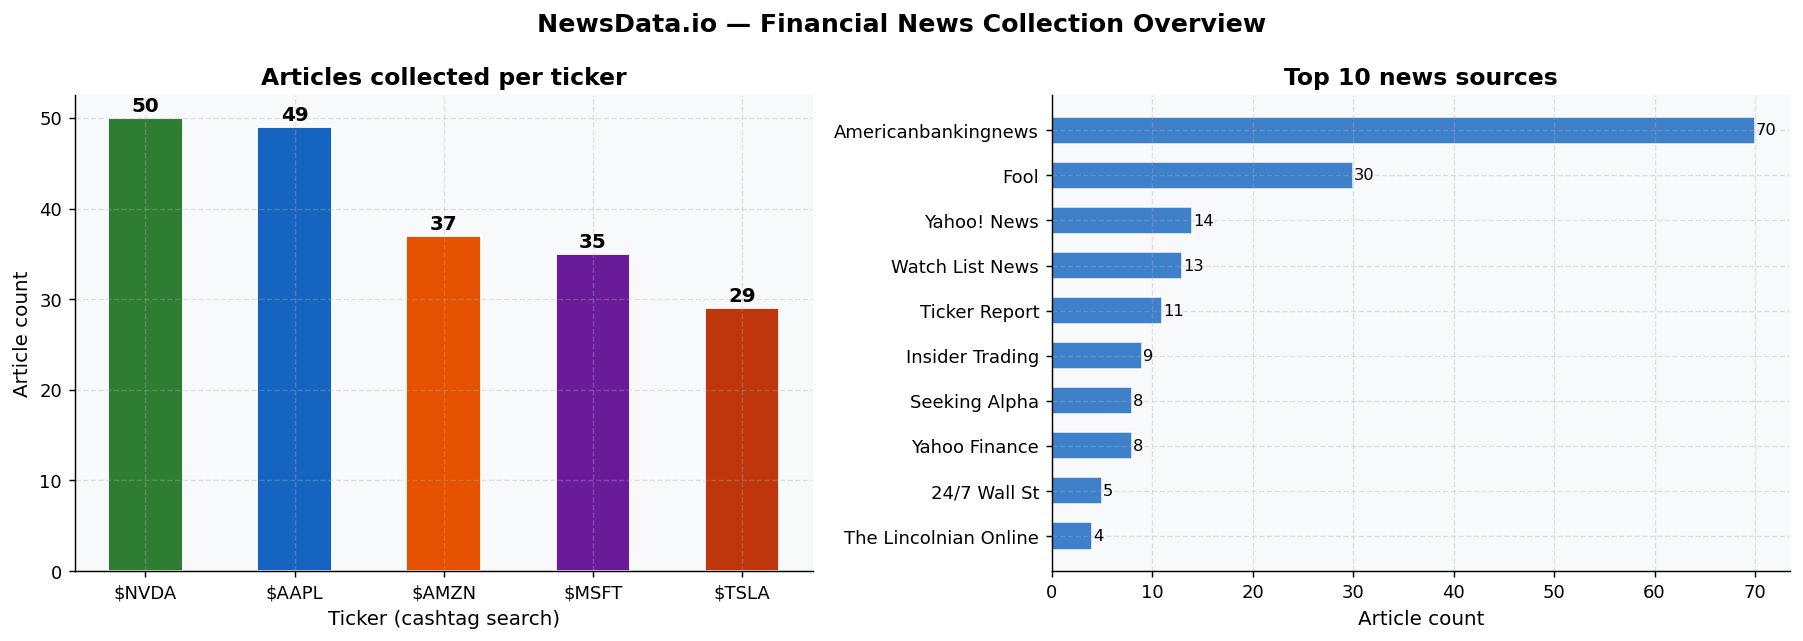

Saved -> /Users/musarashid/market-pulse-nn/reports/figures/01_newsdata_overview.png
Saved newsdata_articles.json  (200 articles)
Top sources: {'Americanbankingnews': 70, 'Fool': 30, 'Yahoo! News': 14}


In [18]:
# =============================================================================
# CELL 17 | Plot 5 — NewsData.io Coverage Overview + Save
#
# Two panels:
#   Left  : Article count per ticker — confirms balanced coverage across
#           all five tickers we are tracking.
#   Right : Top 10 news sources by article count — shows which publishers
#           dominate our dataset (useful context for sentiment quality).
#
# Then saves the full DataFrame to data/raw/twitter/newsdata_articles.json
# (stored in the twitter/ folder to match the pipeline's data structure).
# =============================================================================

newsdata_manifest = {}

if not newsdata_df.empty:

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, (ax_ticker, ax_source) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "NewsData.io — Financial News Collection Overview",
        fontsize=14, fontweight="bold"
    )

    # ── Left: Article count per ticker ────────────────────────────────────────
    ticker_counts = newsdata_df["ticker_ref"].value_counts()
    bar_colors    = [TICKER_COLORS.get(t, "#888") for t in ticker_counts.index]

    bars = ax_ticker.bar(
        [f"${t}" for t in ticker_counts.index],
        ticker_counts.values,
        color=bar_colors,
        width=0.5,
        edgecolor="white",
    )
    for bar, val in zip(bars, ticker_counts.values):
        ax_ticker.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(val),
            ha="center", va="bottom", fontsize=11, fontweight="bold",
        )
    ax_ticker.set_title("Articles collected per ticker")
    ax_ticker.set_ylabel("Article count")
    ax_ticker.set_xlabel("Ticker (cashtag search)")

    # ── Right: Top 10 news sources ────────────────────────────────────────────
    top_sources = (
        newsdata_df["source_name"]
        .replace("", "Unknown")
        .fillna("Unknown")
        .value_counts()
        .head(10)
    )

    source_bars = ax_source.barh(
        top_sources.index[::-1],   # reverse so highest is at top
        top_sources.values[::-1],
        color="#1565C0",
        alpha=0.82,
        edgecolor="white",
        height=0.6,
    )
    for bar, val in zip(source_bars, top_sources.values[::-1]):
        ax_source.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center", fontsize=9,
        )
    ax_source.set_title("Top 10 news sources")
    ax_source.set_xlabel("Article count")

    plt.tight_layout()
    plt.savefig(CFG.FIGURES / "01_newsdata_overview.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved -> {CFG.FIGURES / '01_newsdata_overview.png'}")

    # ── Save ──────────────────────────────────────────────────────────────────
    out_path = CFG.TWITTER / "newsdata_articles.json"
    export   = newsdata_df.copy()
    export["published_at"] = export["published_at"].apply(
        lambda ts: ts.isoformat() if pd.notna(ts) else None
    )
    export.to_json(out_path, orient="records", indent=2, force_ascii=False)

    newsdata_manifest = {
        "file"           : out_path.name,
        "rows"           : len(newsdata_df),
        "by_ticker"      : newsdata_df["ticker_ref"].value_counts().to_dict(),
        "unique_sources" : int(newsdata_df["source_name"].nunique()),
        "start"          : str(newsdata_df["published_at"].min()),
        "end"            : str(newsdata_df["published_at"].max()),
        "saved_at"       : datetime.now().isoformat(timespec="seconds"),
    }
    print(f"Saved {out_path.name}  ({len(newsdata_df):,} articles)")
    print(f"Top sources: {dict(list(top_sources.items())[:3])}")

else:
    newsdata_manifest = {
        "available": False,
        "reason"   : "API key not configured — add NEWSDATA_API_KEY to .env",
    }
    print("No NewsData.io articles — manifest reflects unavailable status.")
    print("Add NEWSDATA_API_KEY to .env and re-run this cell.")

---
## 4b · Alpha Vantage — Historical Financial News Sentiment

This is the most important text data source in the project.
RSS and NewsData.io only serve **recent** articles (2024–2026).
Alpha Vantage News Sentiment covers **2021–2024** — aligned exactly
with our price training window.

**Critical advantage — pre-computed sentiment scores:**
Alpha Vantage returns sentiment already scored per article AND per ticker:
- `av_sentiment_score`  : ticker-specific score in [-1, +1]
- `relevance_score`     : how relevant the article is to that ticker [0, 1]
- `overall_sentiment_score` : article-level score [-1, +1]

These scores feed **directly into Notebook 03 as features** without needing
FinBERT to re-score them. FinBERT will re-score RSS and NewsData articles only.

**Fetching strategy:**
5 tickers × 4 years = 20 requests — fits within the 25 req/day free limit.
Each request returns 50 articles → ~1,000 articles covering 2021–2024.

**Schema produced:**

| Column | Type | Notes |
|---|---|---|
| `article_id` | str | MD5 hash of article URL |
| `title` | str | Article headline |
| `summary` | str | Article summary |
| `source` | str | Publisher name |
| `published_at` | datetime (UTC) | Publication timestamp |
| `ticker_ref` | str | Ticker this article was fetched for |
| `relevance_score` | float | Ticker relevance [0, 1] |
| `av_sentiment_score` | float | Ticker-specific sentiment [-1, +1] |
| `av_sentiment_label` | str | Bullish / Somewhat-Bullish / Neutral / Somewhat-Bearish / Bearish |
| `overall_sentiment_score` | float | Article-level sentiment [-1, +1] |
| `overall_sentiment_label` | str | Article-level label |
| `text` | str | `title + ". " + summary` — input to FinBERT |

In [6]:
# =============================================================================
# CELL 18b | Alpha Vantage — Historical News Sentiment Fetch
#
# Fetches 2021–2024 financial news for each ticker using the
# Alpha Vantage NEWS_SENTIMENT endpoint.
#
# Strategy: 5 tickers × 4 years = 20 requests (within 25 req/day free limit)
# Each request returns up to 50 articles → ~1,000 articles total.
#
# Pre-computed sentiment scores (av_sentiment_score, relevance_score) are
# extracted here and used DIRECTLY as features in Notebook 03,
# bypassing the need to run FinBERT on these articles.
#
# Rate limit: 15-second sleep between requests keeps us safe.
# =============================================================================

import hashlib
import requests as req_lib

# Reload config to pick up the updated config.py
import importlib, sys
if "config" in sys.modules:
    importlib.reload(sys.modules["config"])
from config import CFG

AV_BASE_URL = "https://www.alphavantage.co/query"

# Year boundaries — each year is one API request per ticker
YEAR_WINDOWS = {
    "2021": ("20210101T0000", "20211231T2359"),
    "2022": ("20220101T0000", "20221231T2359"),
    "2023": ("20230101T0000", "20231231T2359"),
    "2024": ("20240101T0000", "20241231T2359"),
}


def check_av_key(api_key: str) -> bool:
    """Quick validation of the Alpha Vantage API key."""
    if not api_key or api_key == "your_alphavantage_key_here":
        print("WARN: ALPHAVANTAGE_API_KEY not set in .env")
        return False
    r = req_lib.get(
        AV_BASE_URL,
        params={
            "function": "NEWS_SENTIMENT",
            "tickers" : "AAPL",
            "limit"   : 1,
            "apikey"  : api_key,
        },
        timeout=15,
    )
    data = r.json()
    if "feed" in data:
        print(f"Alpha Vantage key valid.")
        return True
    elif "Note" in data:
        print("WARN: Alpha Vantage rate limit hit — wait 1 minute and retry.")
        return False
    elif "Information" in data:
        print(f"WARN: {data['Information']}")
        return False
    else:
        print(f"WARN: Unexpected response: {list(data.keys())}")
        return False

def parse_av_article(item: dict, ticker: str):
    """
    Parses a single Alpha Vantage article dict into our schema.

    Extracts the ticker-specific sentiment score (more precise than the
    overall article sentiment) plus the relevance score.
    Returns None if the article has no data for our ticker.
    """
    # Find the ticker-specific sentiment entry
    ticker_sentiment = {}
    for ts in item.get("ticker_sentiment", []):
        if ts.get("ticker", "").upper() == ticker.upper():
            ticker_sentiment = ts
            break

    # Skip articles where our ticker has very low relevance
    relevance = float(ticker_sentiment.get("relevance_score", 0))
    if relevance < 0.1 and ticker_sentiment:
        return None

    title   = (item.get("title",   "") or "").strip()
    summary = (item.get("summary", "") or "").strip()
    url     = item.get("url", "")

    # Parse the timestamp — AV format: "20210115T143022"
    raw_time = item.get("time_published", "")
    try:
        published_at = pd.Timestamp(
            f"{raw_time[:4]}-{raw_time[4:6]}-{raw_time[6:8]} "
            f"{raw_time[9:11]}:{raw_time[11:13]}:{raw_time[13:15]}",
            tz="UTC",
        )
    except Exception:
        published_at = pd.NaT

    return {
        # Unique ID: MD5 hash of URL (stable across runs)
        "article_id"              : hashlib.md5(url.encode()).hexdigest()[:16],
        "title"                   : title,
        "summary"                 : summary,
        "source"                  : item.get("source", ""),
        "published_at"            : published_at,
        "ticker_ref"              : ticker,
        # Ticker-specific fields (more precise than overall)
        "relevance_score"         : relevance,
        "av_sentiment_score"      : float(ticker_sentiment.get("ticker_sentiment_score", 0)),
        "av_sentiment_label"      : ticker_sentiment.get("ticker_sentiment_label", "Neutral"),
        # Article-level fields (backup / cross-check)
        "overall_sentiment_score" : float(item.get("overall_sentiment_score", 0)),
        "overall_sentiment_label" : item.get("overall_sentiment_label", "Neutral"),
        # Text for FinBERT re-scoring in Notebook 02
        "text"                    : f"{title}. {summary}".strip(),
    }


def fetch_av_news(api_key: str, tickers: list, year_windows: dict) -> pd.DataFrame:
    """
    Fetches historical news sentiment for all tickers across all years.

    Parameters
    ----------
    api_key      : Alpha Vantage API key
    tickers      : list of ticker symbols
    year_windows : dict mapping year -> (time_from, time_to)

    Returns
    -------
    pd.DataFrame with pre-computed sentiment scores, one row per article
    """
    all_articles = []
    seen_ids     = set()
    total_requests = 0
    max_requests   = 24   # stay 1 under the 25/day limit as safety margin

    for ticker in tickers:
        print(f"\n  {ticker}:")

        for year, (time_from, time_to) in year_windows.items():
            if total_requests >= max_requests:
                print(f"    WARN: Reached {max_requests} request limit for today.")
                print(f"    Re-run tomorrow to fetch remaining tickers/years.")
                break

            print(f"    {year} ...", end=" ", flush=True)

            try:
                r = req_lib.get(
                    AV_BASE_URL,
                    params={
                        "function" : "NEWS_SENTIMENT",
                        "tickers"  : ticker,
                        "time_from": time_from,
                        "time_to"  : time_to,
                        "limit"    : 50,          # free tier max
                        "sort"     : "LATEST",
                        "apikey"   : api_key,
                    },
                    timeout=20,
                )
                total_requests += 1
                data = r.json()

            except Exception as exc:
                print(f"Error: {exc}")
                time.sleep(CFG.AV_SLEEP_BETWEEN)
                continue

            # Handle API-level errors
            if "Note" in data:
                print("Rate limited — sleeping 60s ...")
                time.sleep(60)
                continue
            if "Information" in data:
                print(f"API message: {data['Information']}")
                break

            feed = data.get("feed", [])
            if not feed:
                print(f"0 articles")
                time.sleep(CFG.AV_SLEEP_BETWEEN)
                continue

            count = 0
            for item in feed:
                parsed = parse_av_article(item, ticker)
                if parsed is None:
                    continue
                aid = parsed["article_id"]
                if aid in seen_ids:
                    continue
                seen_ids.add(aid)
                all_articles.append(parsed)
                count += 1

            print(f"{count} articles | {total_requests} requests used today")
            time.sleep(CFG.AV_SLEEP_BETWEEN)   # respect rate limit

    if not all_articles:
        print("\nNo Alpha Vantage articles collected.")
        return pd.DataFrame()

    df = pd.DataFrame(all_articles)
    df["published_at"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
    df = df.sort_values("published_at").reset_index(drop=True)

    print(f"\n{'─'*55}")
    print(f"Total articles     : {len(df):,}")
    print(f"Date range         : {df['published_at'].min().date()} -> {df['published_at'].max().date()}")
    print(f"Unique sources     : {df['source'].nunique()}")
    print(f"API requests used  : {total_requests}/25 today")
    print(f"{'─'*55}")

    return df


# ── Execute ───────────────────────────────────────────────────────────────────
print("── Alpha Vantage historical news fetch ──────────────────────────────")

av_key_valid = check_av_key(CFG.ALPHAVANTAGE_API_KEY)
av_df        = pd.DataFrame()

if av_key_valid:
    print(f"Fetching {len(CFG.TICKERS)} tickers × {len(YEAR_WINDOWS)} years "
          f"= {len(CFG.TICKERS) * len(YEAR_WINDOWS)} requests ...\n"
          f"Estimated time: ~{len(CFG.TICKERS) * len(YEAR_WINDOWS) * CFG.AV_SLEEP_BETWEEN // 60} minutes")
    print("─" * 55)

    av_df = fetch_av_news(CFG.ALPHAVANTAGE_API_KEY, CFG.TICKERS, YEAR_WINDOWS)
else:
    print("Alpha Vantage fetch skipped.")

── Alpha Vantage historical news fetch ──────────────────────────────
Alpha Vantage key valid.
Fetching 5 tickers × 4 years = 20 requests ...
Estimated time: ~5 minutes
───────────────────────────────────────────────────────

  AAPL:
    2021 ... 50 articles | 1 requests used today
    2022 ... 50 articles | 2 requests used today
    2023 ... 50 articles | 3 requests used today
    2024 ... 50 articles | 4 requests used today

  TSLA:
    2021 ... 49 articles | 5 requests used today
    2022 ... 48 articles | 6 requests used today
    2023 ... 48 articles | 7 requests used today
    2024 ... 48 articles | 8 requests used today

  NVDA:
    2021 ... 43 articles | 9 requests used today
    2022 ... 42 articles | 10 requests used today
    2023 ... 39 articles | 11 requests used today
    2024 ... 39 articles | 12 requests used today

  MSFT:
    2021 ... 37 articles | 13 requests used today
    2022 ... 37 articles | 14 requests used today
    2023 ... 31 articles | 15 requests used toda

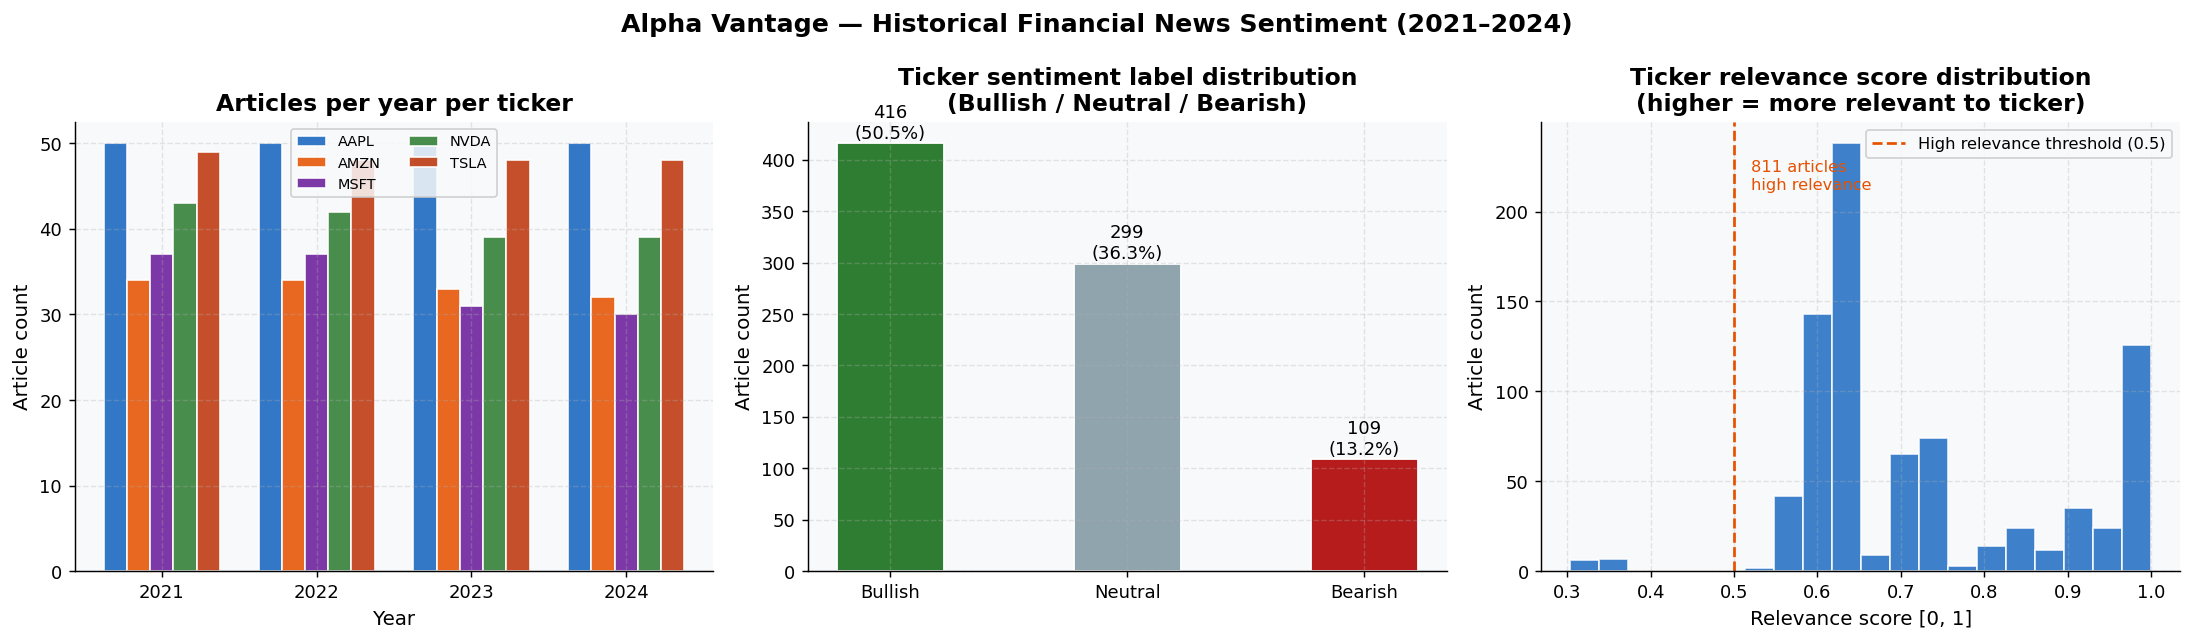

Saved -> /Users/musarashid/market-pulse-nn/reports/figures/01_alphavantage_overview.png

── Sentiment score statistics ───────────────────────────────────
count   824.0000
mean      0.1493
std       0.2468
min      -0.7291
25%       0.0562
50%       0.1860
75%       0.3249
max       0.8643

Bullish  : 416 articles
Neutral  : 299 articles
Bearish  : 109 articles

High relevance (>0.5): 811 / 824 articles

Saved alphavantage_news.json  (824 articles)
By ticker: {'AAPL': 200, 'TSLA': 193, 'NVDA': 163, 'MSFT': 135, 'AMZN': 133}
By year  : {2021: 213, 2022: 211, 2023: 201, 2024: 199}


In [7]:
# =============================================================================
# CELL 18c | Alpha Vantage — Visualisation + Save
#
# Three panels showing the quality and distribution of the fetched data:
#   Left   : Articles per year per ticker (grouped bar) — confirms
#            temporal coverage aligns with our 2021-2024 price window.
#   Centre : Sentiment label distribution — shows the natural Bullish /
#            Neutral / Bearish breakdown in financial news.
#   Right  : Relevance score distribution — articles with score > 0.5
#            are highly relevant to the ticker, < 0.2 are tangential.
#
# Then saves to data/raw/prices/ alongside the OHLCV CSVs so Notebook 03
# can find both price and sentiment in one place.
# =============================================================================

av_manifest = {}

if not av_df.empty:

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, (ax_year, ax_sent, ax_rel) = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(
        "Alpha Vantage — Historical Financial News Sentiment (2021–2024)",
        fontsize=14, fontweight="bold",
    )

    # ── Left: Articles per year per ticker (grouped bar) ──────────────────────
    av_df["year"] = av_df["published_at"].dt.year
    year_ticker   = (
        av_df.groupby(["year", "ticker_ref"])
        .size()
        .unstack(fill_value=0)
    )

    x      = np.arange(len(year_ticker.index))
    n_tick = len(year_ticker.columns)
    width  = 0.15

    for i, ticker in enumerate(year_ticker.columns):
        color  = TICKER_COLORS.get(ticker, "#888")
        offset = (i - n_tick / 2 + 0.5) * width
        bars   = ax_year.bar(
            x + offset,
            year_ticker[ticker],
            width,
            label=ticker,
            color=color,
            alpha=0.87,
            edgecolor="white",
        )

    ax_year.set_xticks(x)
    ax_year.set_xticklabels(year_ticker.index.astype(str))
    ax_year.set_title("Articles per year per ticker")
    ax_year.set_ylabel("Article count")
    ax_year.set_xlabel("Year")
    ax_year.legend(fontsize=8, ncols=2)

    # ── Centre: Sentiment label distribution ──────────────────────────────────
    # Map all labels to 3 clean categories for clarity
    label_map = {
        "Bullish"          : "Bullish",
        "Somewhat-Bullish" : "Bullish",
        "Neutral"          : "Neutral",
        "Somewhat-Bearish" : "Bearish",
        "Bearish"          : "Bearish",
    }
    av_df["sentiment_3"] = av_df["av_sentiment_label"].map(label_map).fillna("Neutral")
    sent_counts = av_df["sentiment_3"].value_counts()

    sent_colors = {
        "Bullish" : "#2E7D32",
        "Neutral" : "#90A4AE",
        "Bearish" : "#B71C1C",
    }
    bars_sent = ax_sent.bar(
        sent_counts.index,
        sent_counts.values,
        color=[sent_colors.get(l, "#888") for l in sent_counts.index],
        width=0.45,
        edgecolor="white",
    )
    for bar, val in zip(bars_sent, sent_counts.values):
        pct = val / len(av_df) * 100
        ax_sent.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10,
        )
    ax_sent.set_title("Ticker sentiment label distribution\n(Bullish / Neutral / Bearish)")
    ax_sent.set_ylabel("Article count")

    # ── Right: Relevance score distribution (histogram) ───────────────────────
    ax_rel.hist(
        av_df["relevance_score"],
        bins=20,
        color="#1565C0",
        alpha=0.82,
        edgecolor="white",
    )
    ax_rel.axvline(0.5, color="#E65100", linestyle="--", linewidth=1.5,
                   label="High relevance threshold (0.5)")
    ax_rel.set_title("Ticker relevance score distribution\n(higher = more relevant to ticker)")
    ax_rel.set_xlabel("Relevance score [0, 1]")
    ax_rel.set_ylabel("Article count")
    ax_rel.legend(fontsize=9)

    high_rel = (av_df["relevance_score"] >= 0.5).sum()
    ax_rel.text(
        0.52, ax_rel.get_ylim()[1] * 0.85,
        f"{high_rel:,} articles\nhigh relevance",
        fontsize=9, color="#E65100",
    )

    plt.tight_layout()
    plt.savefig(CFG.FIGURES / "01_alphavantage_overview.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved -> {CFG.FIGURES / '01_alphavantage_overview.png'}")

    # ── Print sentiment stats ──────────────────────────────────────────────────
    print("\n── Sentiment score statistics ───────────────────────────────────")
    print(av_df["av_sentiment_score"].describe().round(4).to_string())
    print(f"\nBullish  : {(av_df['sentiment_3'] == 'Bullish').sum():,} articles")
    print(f"Neutral  : {(av_df['sentiment_3'] == 'Neutral').sum():,} articles")
    print(f"Bearish  : {(av_df['sentiment_3'] == 'Bearish').sum():,} articles")
    print(f"\nHigh relevance (>0.5): {high_rel:,} / {len(av_df):,} articles")

    # ── Save ──────────────────────────────────────────────────────────────────
    # Save to data/raw/news/ alongside Reuters articles
    # Notebook 03 will merge both sources into daily sentiment features
    out_path = CFG.NEWS / "alphavantage_news.json"
    export   = av_df.drop(columns=["year", "sentiment_3"], errors="ignore").copy()
    export["published_at"] = export["published_at"].apply(
        lambda ts: ts.isoformat() if pd.notna(ts) else None
    )
    export.to_json(out_path, orient="records", indent=2, force_ascii=False)

    av_manifest = {
        "file"                : out_path.name,
        "rows"                : len(av_df),
        "by_ticker"           : av_df["ticker_ref"].value_counts().to_dict(),
        "by_year"             : av_df["year"].value_counts().sort_index().to_dict(),
        "start"               : str(av_df["published_at"].min().date()),
        "end"                 : str(av_df["published_at"].max().date()),
        "high_relevance_count": int(high_rel),
        "sentiment_breakdown" : av_df["sentiment_3"].value_counts().to_dict(),
        "saved_at"            : datetime.now().isoformat(timespec="seconds"),
    }

    print(f"\nSaved {out_path.name}  ({len(av_df):,} articles)")
    print(f"By ticker: {av_manifest['by_ticker']}")
    print(f"By year  : {av_manifest['by_year']}")

else:
    av_manifest = {"available": False, "reason": "API key not configured"}
    print("No Alpha Vantage data — add ALPHAVANTAGE_API_KEY to .env and re-run.")

---
## 5 · Data Coverage Summary

Before handing off to the sentiment notebook we verify:
1. **Record counts** -- is there enough data for meaningful model training?
2. **Temporal alignment** -- do all sources overlap with the price timeline?
3. **Coverage gaps** -- which weeks have missing text data (need imputation)?

The coverage heatmap drives imputation decisions in Notebook 03.

Source                  Records  Date range
-----------------------------------------------------------------
  Yahoo Finance           1,003  2021-01-04 -> 2024-12-27
  RSS News                   77  2024-02-27 -> 2026-05-11
  NewsData.io               200  2026-05-09 -> 2026-05-11
  Alpha Vantage             824  2021-11-18 -> 2024-12-31
  Reddit                    N/A  (pending API approval)


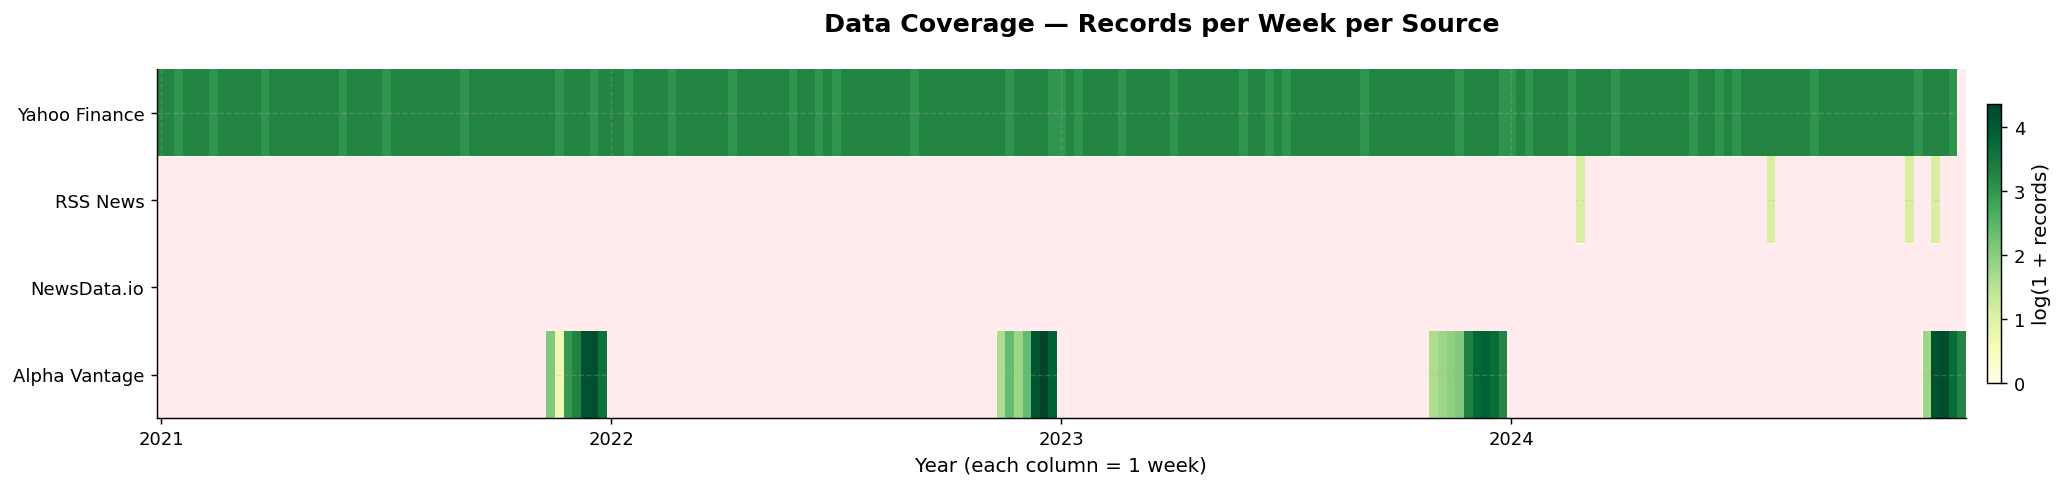

Saved -> /Users/musarashid/market-pulse-nn/reports/figures/01_coverage_heatmap.png
Light red cells = gaps requiring forward-fill imputation in Notebook 03.

Manifest saved: /Users/musarashid/market-pulse-nn/data/raw/manifest.json

-- Sources available for Notebook 02 --
  OK  yahoo_finance               N/A records
  OK  rss_news                     77 records
  OK  newsdata                    200 records
  OK  alphavantage                824 records
  --  reddit                      N/A records

  Notebook 01 complete.
  Next -> 02_sentiment_analysis.ipynb


In [19]:
# =============================================================================
# CELL 19 | Data Coverage Heatmap + Master Manifest
#
# Builds a weekly coverage matrix: rows = sources, cols = ISO weeks.
# White/light cells = gaps (zero records that week).
# These gaps will be forward-filled with the last known sentiment score
# in Notebook 03 (Feature Engineering).
#
# Then writes manifest.json to data/raw/ so Notebook 02 knows what is
# available and where to find each raw file.
# =============================================================================

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 65)
print(f"{'Source':<22} {'Records':>8}  {'Date range'}")
print("-" * 65)

if price_data:
    ref = price_data[CFG.TICKERS[0]]
    print(f"  {'Yahoo Finance':<20} {len(ref):>8,}  "
          f"{ref['date'].min().date()} -> {ref['date'].max().date()}")
else:
    print(f"  {'Yahoo Finance':<20} {'N/A':>8}")

if not news_df.empty:
    print(f"  {'RSS News':<20} {len(news_df):>8,}  "
          f"{news_df['published'].min().date()} -> {news_df['published'].max().date()}")
else:
    print(f"  {'RSS News':<20} {'N/A':>8}  (not collected)")

if not newsdata_df.empty:
    print(f"  {'NewsData.io':<20} {len(newsdata_df):>8,}  "
          f"{newsdata_df['published_at'].min().date()} -> {newsdata_df['published_at'].max().date()}")
else:
    print(f"  {'NewsData.io':<20} {'N/A':>8}  (key not configured)")

if not av_df.empty:
    print(f"  {'Alpha Vantage':<20} {len(av_df):>8,}  "
          f"{av_df['published_at'].min().date()} -> {av_df['published_at'].max().date()}")
else:
    print(f"  {'Alpha Vantage':<20} {'N/A':>8}  (fetch in progress)")

# Reddit — only show if it was collected
try:
    if not reddit_df.empty:
        print(f"  {'Reddit':<20} {len(reddit_df):>8,}  "
              f"{reddit_df['created_utc'].min().date()} -> {reddit_df['created_utc'].max().date()}")
    else:
        print(f"  {'Reddit':<20} {'N/A':>8}  (pending API approval)")
except NameError:
    print(f"  {'Reddit':<20} {'N/A':>8}  (pending API approval)")

print("=" * 65)


# ── Weekly coverage heatmap ───────────────────────────────────────────────────
weeks      = pd.date_range(CFG.HIST_START, CFG.HIST_END, freq="W-MON")
src_labels = ["Yahoo Finance", "RSS News", "NewsData.io", "Alpha Vantage"]
cov_matrix = np.zeros((len(src_labels), len(weeks)))


def _fill(df, date_col, row):
    """Counts records per ISO week and fills the coverage matrix row."""
    if df is None or df.empty:
        return
    dates = pd.to_datetime(df[date_col], utc=True, errors="coerce").dropna()
    if dates.dt.tz is not None:
        dates = dates.dt.tz_localize(None)
    for j, wk in enumerate(weeks):
        we = wk + pd.Timedelta(days=7)
        cov_matrix[row, j] = ((dates >= wk) & (dates < we)).sum()


# Yahoo Finance
if price_data:
    all_price = pd.concat([df[["date"]] for df in price_data.values()])
    _fill(all_price, "date", 0)

# RSS News
if not news_df.empty:
    _fill(news_df.rename(columns={"published": "date"}), "date", 1)

# NewsData.io
if not newsdata_df.empty:
    _fill(newsdata_df.rename(columns={"published_at": "date"}), "date", 2)

# Alpha Vantage — covers 2021-2024 aligned with price data
try:
    if not av_df.empty:
        _fill(av_df.rename(columns={"published_at": "date"}), "date", 3)
except NameError:
    pass

# Reddit — safe check in case variable never defined
try:
    if not reddit_df.empty:
        _fill(reddit_df.rename(columns={"created_utc": "date"}), "date", 3)
except NameError:
    pass   # Reddit not collected yet — row stays zero


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 3.8))
fig.suptitle(
    "Data Coverage — Records per Week per Source",
    fontsize=14, fontweight="bold"
)

im = ax.imshow(
    np.log1p(cov_matrix),
    aspect="auto",
    cmap="YlGn",
    interpolation="nearest",
)

ax.set_yticks(range(len(src_labels)))
ax.set_yticklabels(src_labels)

year_ticks  = [i for i, w in enumerate(weeks) if w.month == 1 and w.day <= 7]
year_labels = [str(weeks[i].year) for i in year_ticks]
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels)
ax.set_xlabel("Year (each column = 1 week)")

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.01)
cbar.set_label("log(1 + records)")

# Highlight gap weeks (zero coverage) in light red
zr, zc = np.where(cov_matrix == 0)
for r, c in zip(zr, zc):
    ax.add_patch(plt.Rectangle(
        (c - 0.5, r - 0.5), 1, 1,
        fill=True, facecolor="#FFEBEE", edgecolor="none", zorder=2,
    ))

plt.tight_layout()
plt.savefig(CFG.FIGURES / "01_coverage_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved -> {CFG.FIGURES / '01_coverage_heatmap.png'}")
print("Light red cells = gaps requiring forward-fill imputation in Notebook 03.")


# ── Write master manifest.json ────────────────────────────────────────────────
# Collect manifests — use empty dict as fallback for any uncollected source
_price_manifest    = price_manifest    if "price_manifest"    in dir() else {}
_news_manifest     = news_manifest     if "news_manifest"     in dir() else {}
_newsdata_manifest = newsdata_manifest if "newsdata_manifest" in dir() else {}
_reddit_manifest   = reddit_manifest   if "reddit_manifest"   in dir() else {
    "available": False, "reason": "Pending API approval"
}

manifest = {
    "generated_at" : datetime.now().isoformat(timespec="seconds"),
    "date_range"   : {"start": CFG.HIST_START, "end": CFG.HIST_END},
    "tickers"      : CFG.TICKERS,
    "sources"      : {
        "yahoo_finance": _price_manifest,
        "rss_news"     : _news_manifest,
        "newsdata"     : _newsdata_manifest,
        "alphavantage" : av_manifest if "av_manifest" in dir() else {"available": False},
        "reddit"       : _reddit_manifest,
    },
    "figures": [
        "01_yf_price_volume.png",
        "01_yf_return_analysis.png",
        "01_news_coverage.png",
        "01_newsdata_overview.png",
        "01_coverage_heatmap.png",
    ],
    "next_notebook": "02_sentiment_analysis.ipynb",
}

manifest_path = CFG.DATA_RAW / "manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"\nManifest saved: {manifest_path}")
print("\n-- Sources available for Notebook 02 --")
for src, info in manifest["sources"].items():
    if isinstance(info, dict):
        ok   = bool(info and info.get("rows", info.get("available", True)))
        rows = info.get("rows", "N/A")
    else:
        ok, rows = False, "N/A"
    status = "OK" if ok else "--"
    print(f"  {status}  {src:<22} {str(rows):>8} records")

print("\n" + "=" * 55)
print("  Notebook 01 complete.")
print("  Next -> 02_sentiment_analysis.ipynb")
print("=" * 55)